<h1> B Data Reduction </h1>

# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact
import numpy as np
import warnings
import statistics as stt
#import bamboolib as bam
#from brokenaxes import brokenaxes
import os
from scipy import stats
from scipy.optimize import curve_fit
from numpy import arange
from collections import deque
import string


# Functions to calculate averages of one measurement point

In [2]:
#Functions to calculate averages of one measurement point


#-------------------------------
# Loading & select different type of data, z.b B, C, U
#-------------------------------

def dirFiles(fDir, ending):
    fNames = []
    for i in os.listdir(fDir):
        if i.endswith(ending):
            fNames.append(i)
    return fNames

#-------------------------------
# used for mapping
#-------------------------------


def selSmpType(dataFiles):
    l = []
    for file in dataFiles:    
        l.append(float(file.split('_')[0]))
    return l


#-------------------------------
# Outlier Correction and Data Conversion from str to float
#-------------------------------
def outlierCorrection(measurement, factorSD):
    element_signal = np.array(measurement)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    return [x for x in measurement if (x > mean - factorSD * sd) and (x < mean + factorSD * sd)]

#-------------------------------
# background substact for 10B with the average of 9.9 and 10.2, think abut each line has to be connected
#-------------------------------

def bacground_sub(folder, select_line, factorSD, factor_B11):
    listname = dirFiles('/Users/mila/Documents/GitHub/boron-main/data/' + folder, 'exp')
    listname.sort()
    average_B = []
    for filename in listname:
        #read data
        df = pd.read_csv('/Users/mila/Documents/GitHub/boron-main/data/' +folder + '/' +filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
        #read all data rows and select useful columns
        fil = df['10B'].str.contains('L|IC|C|H') == True
        endnum = df['10B'][fil].index[0]
        df_data = df[:endnum][['9.9', '10B', '10.2', '11B']].astype(float)
            #seperate two dataframe based on selectline, one is background, one is signal 
        index_select = df_data['10B'] >= select_line
        df_bacground_mean = df_data[~index_select].mean()
        df_signal = df_data.loc[index_select]
            #substract background, substract bulc for 10B and 11B
        df_bacground_sub = df_signal - df_bacground_mean
        df_bacground_sub['10B_bulc_sub'] = df_bacground_sub['10B']-(df_bacground_sub['9.9']+df_bacground_sub['10.2'])/2
        df_bacground_sub['11B_bulc_sub'] = df_bacground_sub['11B']-factor_B11*(df_bacground_sub['9.9']+df_bacground_sub['10.2'])/2
        df_bacground_sub['11B/10B'] = df_bacground_sub['11B_bulc_sub']/df_bacground_sub['10B_bulc_sub'] 

        res = outlierCorrection(df_bacground_sub['11B/10B'], factorSD)
        average_B.append({'filename': filename, '11B/10B_row': np.mean(res), 'se': np.std(res)})
    return (pd.DataFrame(average_B))


#-------------------------------
# regression based on the level from 2-5 you chosed
#-------------------------------

def polynomFit(inp, *args):
    x=inp
    res=0
    for order in range(len(args)):
        res+=args[order] * x**order
    return res


def regression(x, y, ref_stand, order, listname):
    fig, ax = plt.subplots()
    ax.plot(x, y, label='measuered', marker='o', linestyle='none' )
    x_use = np.array(x)
    popt, pcov = curve_fit(polynomFit, xdata=x_use, ydata=y , p0=[0]*(order+1))
    fitData=polynomFit(x_use,*popt)
    ax.plot(x_use, fitData, label='polyn. fit, order '+str(order), linestyle='--' )
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    
    res = []
    for unknown in listname:
        y_unknown = ref_stand / polynomFit(unknown,*popt)
        res.append({'factor': y_unknown})
    return(pd.DataFrame(res))

# Use A get the regression line and calculate

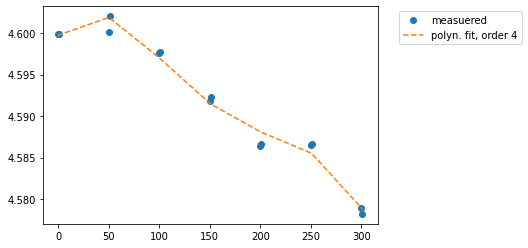

In [50]:
df_data = bacground_sub('2022-11-29 B Std JX AG splitstream_20221129-214242', 0.01, 2, 1)

fil = df_data['filename'].str.contains('A')
df_data_A = df_data[fil]
df_data['filenamber'] = selSmpType(df_data['filename'])
#df_data_A.index
y = df_data_A['11B/10B_row']
x = df_data_A.index.to_numpy()

factor = regression(x,y, 4.05, 4, df_data.index.to_numpy())
df_data['factor'] = factor
df_data['11B/10B_corrected'] = df_data['factor']*df_data['11B/10B_row']
df_data['δ11B'] = ((df_data['11B/10B_corrected']/4.055)-1)*1000
df_data['δ11B_se'] = df_data['δ11B']-(((df_data['11B/10B_corrected']-(df_data['11B/10B_corrected']/100*4.05)-1)*1000))

# Mapping

In [127]:
df_Laser = pd.read_csv('data/seq1_log_20221129_214322.csv', header=0)

res = []
for i in df_data['filenamber']:
    mapping = df_Laser[df_Laser[' Sequence Number']==i].index[0]
    df_data_laser = df_Laser.loc[mapping, [' Laser Energy (mJ)', ' Laser HV (kV)', ' Spot Size (um)', ' Comment']]
    res.append(df_data_laser)

df_data_laser = pd.DataFrame(res).reset_index()
df_final = pd.concat([df_data_laser, df_data], axis = 1)
df_final

,index,Laser Energy (mJ),Laser HV (kV),Spot Size (um),Comment,filename,11B/10B_row,se,factor,11B/10B_corrected,δ11B,δ11B_se,filenamber
0,0,75.130,24.860,285.0,NIST612 gl,001_A.exp,4.599872,0.008199,0.880512,4.050243,-1.173135,-2887.381235,1.0
1,5,75.871,24.893,130.0,NIST612 gl,002_A.exp,4.599898,0.005058,0.880479,4.050112,-1.205389,-2887.287993,2.0
2,10,75.846,24.985,130.0,NIST612 np,003_B.exp,4.597657,0.009258,0.880446,4.047991,-1.728397,-2885.776098,3.0
3,15,75.016,24.904,193.0,NIST612 np,004_B.exp,4.596120,0.008921,0.880416,4.046496,-2.097168,-2884.710065,4.0
4,20,75.664,24.879,193.0,B5,005_C.exp,4.573115,0.008746,0.880386,4.026106,-7.125549,-2870.174158,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,1530,74.499,24.940,285.0,BHVO,307_D.exp,NaN,NaN,0.884763,NaN,NaN,NaN,307.0
307,1535,74.843,24.926,285.0,BHVO,308_D.exp,NaN,NaN,0.884813,NaN,NaN,NaN,308.0
308,1540,74.868,24.869,285.0,NaN,309_U.exp,4.589301,0.009784,0.884865,4.060910,1.457475,-2894.985730,309.0
309,1545,75.054,24.953,285.0,NaN,310_U.exp,4.563725,0.013565,0.884917,4.038517,-4.064825,-2879.022015,310.0


# Testing

In [13]:
results = {'Laser Energy (mJ)': res_energy, 
           'Spot Size (um)': res_spotsize, 'Laser HV (kV)': res_HV}

Laser_res= pd.DataFrame(results)
resss = pd.concat([Laser_res, dfN.reindex(Laser_res.index)], axis=1)

NameError: name 'res_energy' is not defined

In [14]:
def laser_Cond(smp):
    return resss[resss['sequence'].str.contains(smp)]

laser_Cond('A')

NameError: name 'resss' is not defined

### Some old code

In [ ]:
#check for outliers for signal:
    element_signal = np.array(fils)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    final_list_signal = [x for x in fils if (x > mean - factorSD * sd)]
    final_list_signal = [x for x in final_list_signal if (x < mean + factorSD * sd)]
    
#check for outliers for background:
    element_backg = np.array(filw)
    mean = np.mean(element_backg, axis=0)
    sd = np.std(element_backg, axis=0)
    final_list_backg = [x for x in filw if (x > mean - factorSD * sd)]
    final_list_backg = [x for x in final_list_backg if (x < mean + factorSD * sd)]
    

def calculateSingleFile(filename, bg_10B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-02-15 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:
    endnum = df['10B'][df['10B'] == 'L3'].index[0]
#    B_10 = []
    fils = []
    filw = []
#    for i in df['10B'][0:endnum]:
#        B_10.append(float(i)) #conversion to float required, as numbers are stored as str
#    for i in B_10:
    for i in df['10B'][0:endnum]:
        meas = float(i)
        if (meas > bg_10B) == True:
            fils.append(meas)
        else:
            filw.append(meas)

#    outlier_corrected_signal =outlierCorrection(fils, factorSD)
#    outlier_corrected_backg =outlierCorrection(filw, factorSD)

#    B_10_aver = sum(outlier_corrected_signal )/len(outlier_corrected_signal )
#    B_10_backg_aver = sum(outlier_corrected_backg)/len(outlier_corrected_backg)

    B_10_aver = np.mean(outlierCorrection(fils, factorSD))
    B_10_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    
    return(B_10_aver, B_10_backg_aver)


def background_substract_basic(filename, signal_object, select_line, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:

    data_float = data_convert(df[signal_object]) #conversion to float required, as numbers are stored as str
    fils = []
    filw = []
        
    for i in data_float:
        if (i > select_line) == True:
            fils.append(i)
        else:
            filw.append(i)

    signal_aver = np.mean(outlierCorrection(fils, factorSD))
    backg_aver = np.mean(outlierCorrection(filw, factorSD))
    res = signal_aver - backg_aver
    return(res)


def background_substract_interference_bacground(filename, select_line, factorSD, factor_B11):
    
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
    res_bacg_inter_sub = []
    data_interference_left = data_convert(df['9.9'])
    data_interference_right = data_convert(df['10.2'])
    data_B10 = data_convert(df['10B'])
    data_B11 = data_convert(df['11B'])

    bacgrounds = []
    bacgrounds_10 = []
    bacgrounds_11 = []
    bacgrounds_99 = []
    bacgrounds_102 = []
    for i in data_B10:
        if (i < select_line) == True:
            index = data_B10.index(i)
            j = data_B11[index]
            bacgrounds_10.append(i)
            bacgrounds_11.append(j)
            bacgrounds_99.append(i)
            bacgrounds_102.append(j)
    backg10_aver = np.mean(outlierCorrection(bacgrounds_10, factorSD))        
    backg11_aver = np.mean(outlierCorrection(bacgrounds_11, factorSD))        
    backg99_aver = np.mean(outlierCorrection(bacgrounds_10, factorSD))
    backg102_aver = np.mean(outlierCorrection(bacgrounds_102, factorSD))

    for i in data_B10:
        if (i > select_line) == True:
            index = data_convert(df['10B']).index(i)
            interference_left_back_sub = data_interference_left[index] - backg99_aver
            interference_right_back_sub = data_interference_right[index] - backg102_aver
            interference = (interference_left_back_sub + interference_right_back_sub)/2
            res_10 = i - interference - backg10_aver
            res_11 = data_B11[index] - (interference * factor_B11) - backg11_aver
            #offset = res_11/res_10 - 
            res_bacg_inter_sub.append (res_11/res_10)

        res = outlierCorrection(res_bacg_inter_sub, factorSD)
    return np.mean(res)


#-------------------------------
#background substact with the basic method, signal_aver-background_aver
#-------------------------------

def background_substract_basic(filename, signal_object, select_line, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#read all data rows and select useful columns
    fil = df['10B'].str.contains('L|IC|C|H') == True
    endnum = df['10B'][fil].index[0]
    df_data = df[:endnum][['10B', '11B']].astype(float)
#seperate two dataframe based on selectline, one is background, one is signal 
    index_select = df_data[signal_object] >= select_line
    df_bacground_mean = df_data[~filx].mean()
    df_signal = df_data.loc[index_select]
#substract background, substract bulc for 10B and 11B
    df_bacground_sub = df_signal - df_bacground.mean()                            
    res = outlierCorrection(df_bacground_sub['11B']/df_bacground_sub['10B'], factorSD)
    return(res)



dataFiles = dirFiles('data/2022-11-04 Boron measurements', 'exp')
dataFiles.sort()

dataFiles = selSmpType('B')

dataFiles

res = []
for i in dataFiles:
    aver = background_substract_basic(i, '11B', 0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
    Neptune_res = {'sequence': i, 'average':aver}
    res.append(Neptune_res)

x_b = getfilenumber(pd.DataFrame(res)['sequence'], '_')

#def offset(datafile):
 #   res = []
  #  for i in datafile:
   #     res.append(objective(i, a, b, c, d, e, f))
    #return res

#offset(x_b)
res = []
for i in dataFiles:
    aver = background_substract_basic(i, '11B', 0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
    Neptune_res = {'sequence': i, 'average':aver}
    res.append(Neptune_res)
res




def data_convert(data):
    data_float = []
    fil =  (data.str.contains('L|IC|C|H') == True)
    endnum = data[fil].index[0]
    for i in data[0:endnum]:
        data_float.append(float(i))
    return data_float




def selSmpType(dataFiles, smp):
    l = []
    for file in dataFiles:    
        if smp in file.split('_')[1]:
            l.append(file)
    return l

#-------------------------------
# read the number from Neptune filename
#-------------------------------

def getfilenumber(datafile, simbel):
    res = []
    for i in datafile:
        res.append(float(i.split(simbel)[0]))
    return res


#-------------------------------
# average valye calculation
#-------------------------------
def calculate_aver(dataFiles, IC):
    res = []
    for i in dataFiles:
        aver = background_substract_basic(i, '11B',  0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
        Neptune_res = {'sequence': i, 'average':aver}
        res.append(Neptune_res)
        df = pd.DataFrame(res)
        
    return df
